I0000 00:00:1777488573.479610    5381 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777488574.996224    5381 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777488578.622564    5381 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Loading and cleaning Indian Liver Patient data...
Training Logistic Regression...

--- Logistic Regression Metrics ---
Accuracy:  0.7350
Precision: 0.7407
Recall:    0.9639

Training TensorFlow Neural Network...


/home/lhossaine/PycharmProjects/disease-prediction-system/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777488579.371738    5381 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

--- Neural Network Metrics ---
Accuracy:  0.7692
Precision: 0.7692
Recall:    0.9639


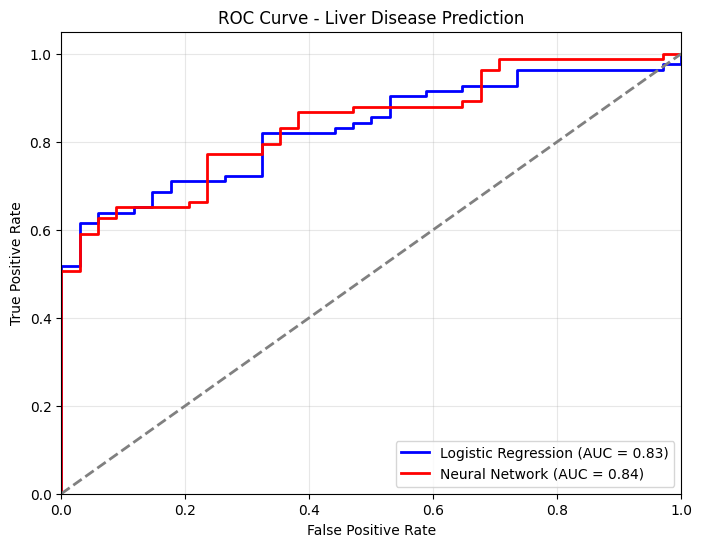

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==========================================
# 1. DATA ENGINEERING PIPELINE
# ==========================================
print("Loading and cleaning Indian Liver Patient data...")
df = pd.read_csv('indian_liver_patient.csv')

# Fix the target trap (Convert '2' for healthy into '0')
df['Dataset'] = df['Dataset'].replace(2, 0)

# Feature Engineering: Convert 'Gender' text to numbers
df = pd.get_dummies(df, drop_first=True)

# Handle Missing Values in the Albumin ratio
imputer = SimpleImputer(strategy='median')
df_cleaned = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Split the data into Features (X) and Target (y)
X = df_cleaned.drop('Dataset', axis=1)
y = df_cleaned['Dataset']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the data (Crucial for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. BASELINE MODEL: LOGISTIC REGRESSION
# ==========================================
print("Training Logistic Regression...")
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Logistic Regression Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, log_preds):.4f}")
print(f"Precision: {precision_score(y_test, log_preds):.4f}")
print(f"Recall:    {recall_score(y_test, log_preds):.4f}")

# ==========================================
# 3. DEEP LEARNING MODEL: NEURAL NETWORK
# ==========================================
print("\nTraining TensorFlow Neural Network...")
nn_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train silently (verbose=0) 
nn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=10, verbose=0) 

nn_probs = nn_model.predict(X_test_scaled).flatten()
nn_preds = (nn_probs > 0.5).astype(int)

print("\n--- Neural Network Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, nn_preds):.4f}")
print(f"Precision: {precision_score(y_test, nn_preds):.4f}")
print(f"Recall:    {recall_score(y_test, nn_preds):.4f}")

# ==========================================
# 4. VISUALIZATION (ROC CURVE)
# ==========================================
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_nn, tpr_nn, color='red', lw=2, label=f'Neural Network (AUC = {roc_auc_nn:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Liver Disease Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()